# 多层感知机 - NumPy 版本

这个例子用一个很小的多层感知机拟合一维非线性函数：

$$
y = x^2
$$

网络结构是：

$$
1 \rightarrow 2 \rightarrow 1
$$

也就是 1 个输入、2 个隐藏层神经元、1 个输出。这个规模很小，适合手工推导前向传播和反向传播。

## 前向传播、反向传播与神经网络节点图

上面一行是神经网络的节点视角，下面一行是对应的向量化计算图。公式视角中的 5 个主节点按从左到右排列；中间的说明框给出两个视角的对应关系。

```mermaid
flowchart TB
    subgraph NN[神经网络节点视角]
        direction LR
        nx["输入层<br/>x"]
        nh1["隐藏节点 h1<br/>ReLU(x*w11 + b11)"]
        nh2["隐藏节点 h2<br/>ReLU(x*w12 + b12)"]
        no["输出层<br/>y_hat"]
        nx -- "w11" --> nh1
        nx -- "w12" --> nh2
        nh1 -- "w21" --> no
        nh2 -- "w22" --> no
    end

    map["映射关系<br/>输入层 x ↔ 输入 x<br/>隐藏节点 h1 ↔ h[0]<br/>隐藏节点 h2 ↔ h[1]<br/>输出层 y_hat ↔ y_hat"]

    subgraph CG[公式 / 计算图视角]
        direction LR
        x["输入 x"]
        z1["z1 = xW1 + b1<br/>W1=[w11,w12], b1=[b11,b12]"]
        h["h = ReLU(z1)<br/>得到 [h1,h2]"]
        yhat["y_hat = hW2 + b2<br/>W2=[w21,w22]^T, b2"]
        loss["L = 1/2 * (y_hat - y)^2<br/>真实值 y"]

        x --> z1 --> h --> yhat --> loss
        loss -. "dL/dy_hat = y_hat - y" .-> yhat
        yhat -. "dL/dh = dL/dy_hat * W2.T" .-> h
        h -. "dL/dz1 = dL/dh * ReLU'(z1)" .-> z1
        z1 -. "dL/dW1 = x.T * dL/dz1, dL/db1 = sum(dL/dz1)" .-> x
        yhat -. "dL/dW2 = h.T * dL/dy_hat, dL/db2 = sum(dL/dy_hat)" .-> h
    end

    NN -.-> map
    map -.-> CG

    classDef data fill:#dff3ff,stroke:#277da1,color:#222;
    classDef op fill:#ecfdf3,stroke:#2b9348,color:#222;
    classDef lossStyle fill:#ffe3e3,stroke:#c92a2a,color:#222;
    classDef neuron fill:#f3e8ff,stroke:#7b2cbf,color:#222;
    classDef mapStyle fill:#f8f9fa,stroke:#adb5bd,color:#222;
    class x,nx data;
    class z1,h,yhat op;
    class loss lossStyle;
    class nh1,nh2,no neuron;
    class map mapStyle;
```


## 1. 单个样本的手推版本

先只看一个样本：

$$
x=2, \quad y=4
$$

初始化参数：

$$
W_1=[1,-1], \quad b_1=[0,0], \quad W_2=[1,1]^T, \quad b_2=0
$$

前向传播：

$$
z_1=xW_1+b_1
$$

$$
h=\operatorname{ReLU}(z_1)
$$

$$
\hat y=hW_2+b_2
$$

$$
L=\frac{1}{2}(\hat y-y)^2
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

font_path = Path("/System/Library/Fonts/Hiragino Sans GB.ttc")
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = "Hiragino Sans GB"
plt.rcParams["axes.unicode_minus"] = False


def relu(x):
    return np.maximum(0, x)


def relu_grad(x):
    return (x > 0).astype(float)


x = np.array([[2.0]])       # shape: (1, 1)
y = np.array([[4.0]])       # shape: (1, 1)

W1 = np.array([[1.0, -1.0]])
b1 = np.array([[0.0, 0.0]])
W2 = np.array([[1.0], [1.0]])
b2 = np.array([[0.0]])

z1 = np.dot(x, W1) + b1
h = relu(z1)
y_hat = np.dot(h, W2) + b2
loss = 0.5 * (y_hat - y) ** 2

print("z1    =", z1)
print("h     =", h)
print("y_hat =", y_hat)
print("loss  =", loss)


z1    = [[ 2. -2.]]
h     = [[2. 0.]]
y_hat = [[2.]]
loss  = [[2.]]


## 2. 反向传播

从损失函数开始往回推：

$$
\frac{\partial L}{\partial \hat y}=\hat y-y
$$

输出层：

$$
\frac{\partial L}{\partial W_2}=h^T\frac{\partial L}{\partial \hat y}
$$

$$
\frac{\partial L}{\partial b_2}=\frac{\partial L}{\partial \hat y}
$$

这里的 $h^T$ 不是为了“凑形状”，而是从每个参数实际参与计算的方式推出来的。

设 batch 里的样本编号是 $n$，隐藏层神经元编号是 $i$，输出编号是 $j$：

$$
\hat y_{n,j}=\sum_i h_{n,i}W_{2,i,j}+b_{2,j}
$$

固定某一个参数 $W_{2,i,j}$，它会被 batch 中所有样本共同使用，所以：

$$
\frac{\partial L}{\partial W_{2,i,j}}
=\sum_n 
\frac{\partial L}{\partial \hat y_{n,j}}
\frac{\partial \hat y_{n,j}}{\partial W_{2,i,j}}
=\sum_n h_{n,i}\frac{\partial L}{\partial \hat y_{n,j}}
$$

这个式子正好就是矩阵乘法 $h^T\frac{\partial L}{\partial \hat y}$ 的第 $(i,j)$ 个元素：

$$
\left(h^T\frac{\partial L}{\partial \hat y}\right)_{i,j}
=\sum_n h_{n,i}\frac{\partial L}{\partial \hat y_{n,j}}
$$

所以 $h^T$ 放在前面，本质上是在沿 batch 维度把每个样本对同一个参数的梯度累加起来。

隐藏层：

$$
\frac{\partial L}{\partial h}=\frac{\partial L}{\partial \hat y}W_2^T
$$

$$
\frac{\partial L}{\partial z_1}=\frac{\partial L}{\partial h}\odot \operatorname{ReLU}'(z_1)
$$

$$
\frac{\partial L}{\partial W_1}=x^T\frac{\partial L}{\partial z_1}
$$

$$
\frac{\partial L}{\partial b_1}=\frac{\partial L}{\partial z_1}
$$


In [2]:
dy = y_hat - y

dW2 = np.dot(h.T, dy)
db2 = dy.sum(axis=0, keepdims=True)

dh = np.dot(dy, W2.T)
dz1 = dh * relu_grad(z1)

dW1 = np.dot(x.T, dz1)
db1 = dz1.sum(axis=0, keepdims=True)

print("dy  =", dy)
print("dW2 =\n", dW2)
print("db2 =", db2)
print("dh  =", dh)
print("dz1 =", dz1)
print("dW1 =", dW1)
print("db1 =", db1)


dy  = [[-2.]]
dW2 =
 [[-4.]
 [ 0.]]
db2 = [[-2.]]
dh  = [[-2. -2.]]
dz1 = [[-2. -0.]]
dW1 = [[-4.  0.]]
db1 = [[-2.  0.]]


这个例子里第二个隐藏神经元的 $z_1=-2$，经过 ReLU 后输出为 0，所以它对应的梯度也被截断为 0。

In [3]:
lr = 0.1

W1_next = W1 - lr * dW1
b1_next = b1 - lr * db1
W2_next = W2 - lr * dW2
b2_next = b2 - lr * db2

print("W1_next =", W1_next)
print("b1_next =", b1_next)
print("W2_next =\n", W2_next)
print("b2_next =", b2_next)


W1_next = [[ 1.4 -1. ]]
b1_next = [[0.2 0. ]]
W2_next =
 [[1.4]
 [1. ]]
b2_next = [[0.2]]


## 3. 批量训练拟合 $y=x^2$

上面只手推了一个样本。下面用同样的公式扩展到一批样本，训练一个小网络去拟合 $[-2,2]$ 上的二次函数。

In [4]:
rng = np.random.default_rng(0)

X = np.linspace(-2, 2, 200).reshape(-1, 1)
Y = X ** 2

num_inputs = 1
num_hiddens = 16
num_outputs = 1

# He 初始化更适合 ReLU。
W1 = rng.standard_normal((num_inputs, num_hiddens)) * np.sqrt(2 / num_inputs)
b1 = np.zeros((1, num_hiddens))
W2 = rng.standard_normal((num_hiddens, num_outputs)) * np.sqrt(2 / num_hiddens)
b2 = np.zeros((1, num_outputs))


def forward(X, W1, b1, W2, b2):
    z1 = np.dot(X, W1) + b1
    h = relu(z1)
    y_hat = np.dot(h, W2) + b2
    cache = (X, z1, h, y_hat)
    return y_hat, cache


def mse_loss(y_hat, y):
    return np.mean((y_hat - y) ** 2) / 2


def backward(cache, y, W2):
    X, z1, h, y_hat = cache
    batch_size = X.shape[0]

    dy = (y_hat - y) / batch_size
    dW2 = np.dot(h.T, dy)
    db2 = dy.sum(axis=0, keepdims=True)

    dh = np.dot(dy, W2.T)
    dz1 = dh * relu_grad(z1)
    dW1 = np.dot(X.T, dz1)
    db1 = dz1.sum(axis=0, keepdims=True)

    return dW1, db1, dW2, db2


In [5]:
lr = 0.03
num_epochs = 3000
losses = []

for epoch in range(num_epochs):
    y_hat, cache = forward(X, W1, b1, W2, b2)
    loss = mse_loss(y_hat, Y)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(cache, Y, W2)
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 500 == 0:
        print(f"epoch {epoch:4d}, loss={loss:.6f}")

print(f"epoch {num_epochs:4d}, loss={losses[-1]:.6f}")


epoch    0, loss=3.086737
epoch  500, loss=0.037523
epoch 1000, loss=0.028098
epoch 1500, loss=0.019635
epoch 2000, loss=0.013198
epoch 2500, loss=0.008659
epoch 3000, loss=0.005627


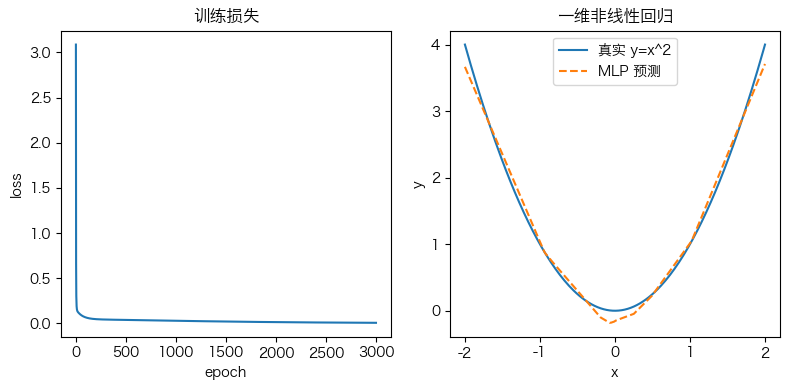

In [6]:
pred, _ = forward(X, W1, b1, W2, b2)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("训练损失")

plt.subplot(1, 2, 2)
plt.plot(X, Y, label="真实 y=x^2")
plt.plot(X, pred, "--", label="MLP 预测")
plt.xlabel("x")
plt.ylabel("y")
plt.title("一维非线性回归")
plt.legend()
plt.tight_layout()
plt.show()


## 4. 小结

这个例子和线性回归很像，区别在于中间多了一层非线性变换：

$$
h=\operatorname{ReLU}(xW_1+b_1)
$$

如果没有 ReLU，多层线性变换仍然等价于一层线性变换，无法拟合 $y=x^2$ 这样的非线性函数。隐藏层加上非线性激活函数，才是多层感知机能够拟合复杂函数的关键。